# Barriers

In [1]:
!pip install osmnx

  Using cached osmnx-2.1.0-py3-none-any.whl.metadata (4.7 kB)
  Using cached shapely-2.1.2-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (6.8 kB)
  Using cached pyproj-3.7.2-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (31 kB)
Using cached osmnx-2.1.0-py3-none-any.whl (104 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.3/33.3 MB 88.9 MB/s eta 0:00:00ta 0:00:01
Using cached pyproj-3.7.2-cp312-cp312-manylinux_2_28_x86_64.whl (9.6 MB)
Using cached shapely-2.1.2-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (3.1 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [osmnx]32m3/5 [geopandas]


In [2]:
import sys
from pathlib import Path

repo_root = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(repo_root))

import cityImage as ci
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

fm.fontManager.addfont("times.ttf")
plt.rcParams["font.family"] = "Times New Roman"

In [3]:
import osmnx as ox
import pandas as pd
import geopandas as gpd
from matplotlib.colors import LinearSegmentedColormap

%matplotlib inline

import warnings
warnings.simplefilter(action="ignore")

## Functions from the cityImage API used in this notebook

This notebook identifies the *structuring barriers* of a city — major roads, railways, water features, coastlines and large parks — and assigns their relationship to the street segments. These barriers operationalise Lynch's *edges*. Acquisition and file IO are delegated to OSMnx and GeoPandas; cityImage keeps the schema conversion and the barrier semantics.

- [barriers_from_osm](../api/cityImage.barriers_from_osm.rst#cityImage.barriers_from_osm) — Download structuring barriers (water, railways, parks, major roads) from OpenStreetMap.
- [plot_gdf](../api/cityImage.plot_gdf.rst#cityImage.plot_gdf) — Plot a single GeoDataFrame with cityImage styling.
- [network_from_osm](../api/cityImage.network_from_osm.rst#cityImage.network_from_osm) — Download a street network from OpenStreetMap and return it as cityImage `nodes` and `edges` GeoDataFrames.
- [clean_network](../api/cityImage.clean_network.rst#cityImage.clean_network) — Clean and simplify the network: remove duplicate nodes/edges, pseudo-nodes, dead-ends and self-loops, and repair topology.
- [along_water](../api/cityImage.along_water.rst#cityImage.along_water) — Flag street segments that run along water barriers.
- [along_within_parks](../api/cityImage.along_within_parks.rst#cityImage.along_within_parks) — Flag street segments that run along or within parks.
- [barriers_along](../api/cityImage.barriers_along.rst#cityImage.barriers_along) — Assign to each edge the barriers it runs along.
- [assign_structuring_barriers](../api/cityImage.assign_structuring_barriers.rst#cityImage.assign_structuring_barriers) — Assign the crossing/structuring-barrier relationship to edges.

For the full list of functions and their parameters, see the [API reference](../api.rst).

In [4]:
# initialise path, names, etc.
city_name = 'Paris'
epsg = 27571
crs = 'EPSG:'+str(epsg)
place = 'Paris, Ile-de-France'

## Barriers Identification

Downloading from OSM

Choose between the following methods:

* `OSMplace`, providing an OSM place name (e.g. City).
* `polygon`, providing a Polygon (coordinates must be in units of latitude-longitude degrees).
* `distance_from_address`, providing a precise address and setting the `distance` parameter.
* `distance_from_point`, providing point coordinates (in units of latitude-longitude degrees) and setting the `distance` parameter to build the bounding box around the point.

In [5]:
download_method = 'OSMplace'

In [6]:
barriers = ci.barriers_from_osm(
    place,
    download_method=download_method,
    crs=crs,
    include_primary=True,
    include_secondary=False,
    parks_min_area=100000,
)
barriers.reset_index(inplace=True, drop=True)
barriers["barrierID"] = barriers.index.astype(int)

In [7]:
# Barriers are already combined by ci.barriers_from_osm().

**Visualisation.** The cell below maps the result using the cityImage plotting helpers such as [plot_gdf](../api/cityImage.plot_gdf.rst#cityImage.plot_gdf); see the [Plotting section of the API reference](../api.rst) for all styling options.

In [8]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Times New Roman"

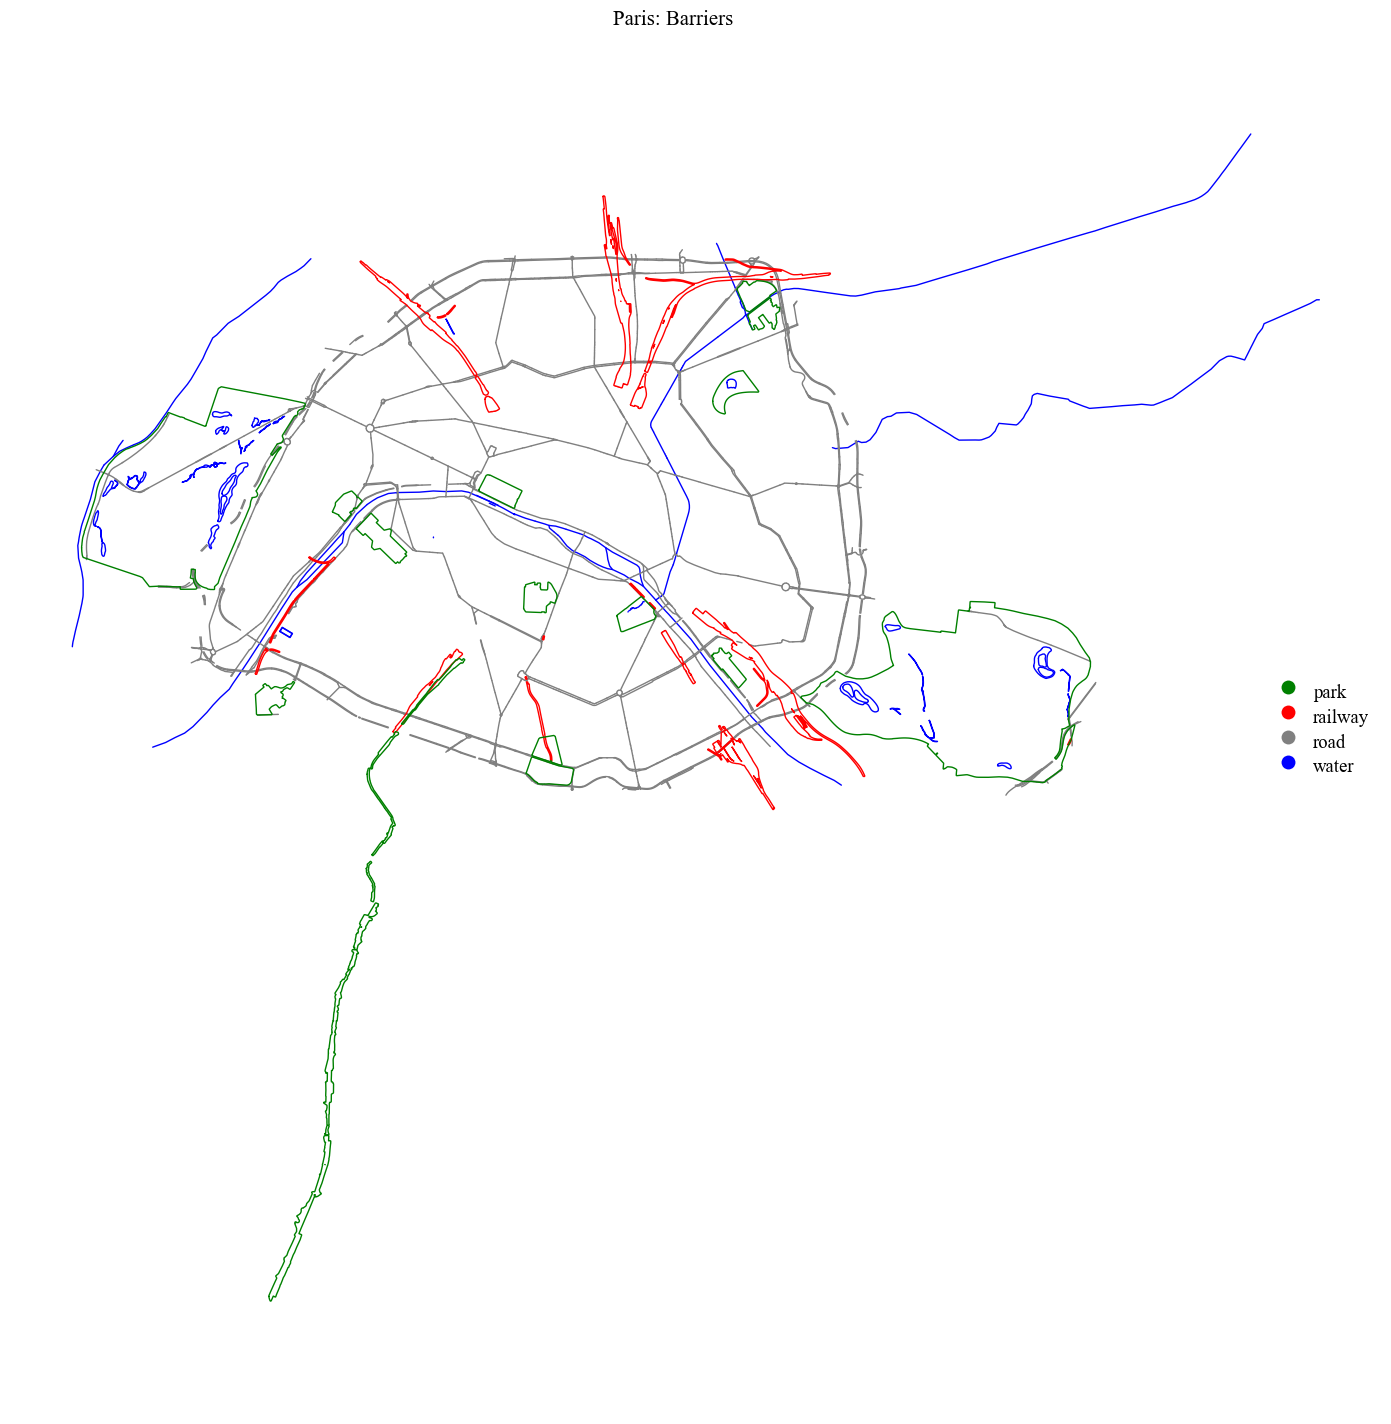

In [9]:
barriers.sort_values(by = 'barrier_type', ascending = False, inplace = True)  
colors = ['green', 'red', 'gray', 'blue']

cmap = LinearSegmentedColormap.from_list('cmap', colors, N=len(colors))
fig = ci.plot_gdf(gdf = barriers, column = 'barrier_type', black_background = False, title = city_name+': Barriers', 
                  legend = True, cmap = cmap)

## Incorporating Barriers into the Street Network
This is an optional step that allows modelling the effect of barriers on pedestrian movement, for exmaple, in agent-based modelling, or in route-choice modelling.

**Download the street network**

Choose between the following methods:

* `OSMplace`, providing an OSM place name (e.g. City).
* `polygon`, providing a Polygon (coordinates must be in units of latitude-longitude degrees).
* `distance_from_address`, providing a precise address and setting the `distance` parameter.
* `distance_from_point`, providing point coordinates (in units of latitude-longitude degrees) and setting the `distance` parameter to build the bounding box around the point.

Downloading the graph and cleaning it (see the notebook *01-Nodes_Paths_fromOSM* for details on the cleaning process)

In [ ]:
nodes_graph, edges_graph = ci.network_from_osm(place, download_method=download_method, network_type="walk", crs=crs)
nodes_graph, edges_graph = ci.clean_network(nodes_graph, edges_graph, dead_ends = True, remove_islands = True,
                            self_loops = True, same_vertexes_edges = True)

**(or) Load it from local path**

In [12]:
input_path = '../output/'+city_name
nodes_graph = gpd.read_file(input_path+'_nodes.gpkg')
edges_graph = gpd.read_file(input_path+'_edges.gpkg')

nodes_graph.index, edges_graph.index  = nodes_graph.nodeID, edges_graph.edgeID
nodes_graph.index.name, edges_graph.index.name  = None, None

**Visualisation.** The cell below maps the result using the cityImage plotting helpers such as [plot_gdf](../api/cityImage.plot_gdf.rst#cityImage.plot_gdf); see the [Plotting section of the API reference](../api.rst) for all styling options.

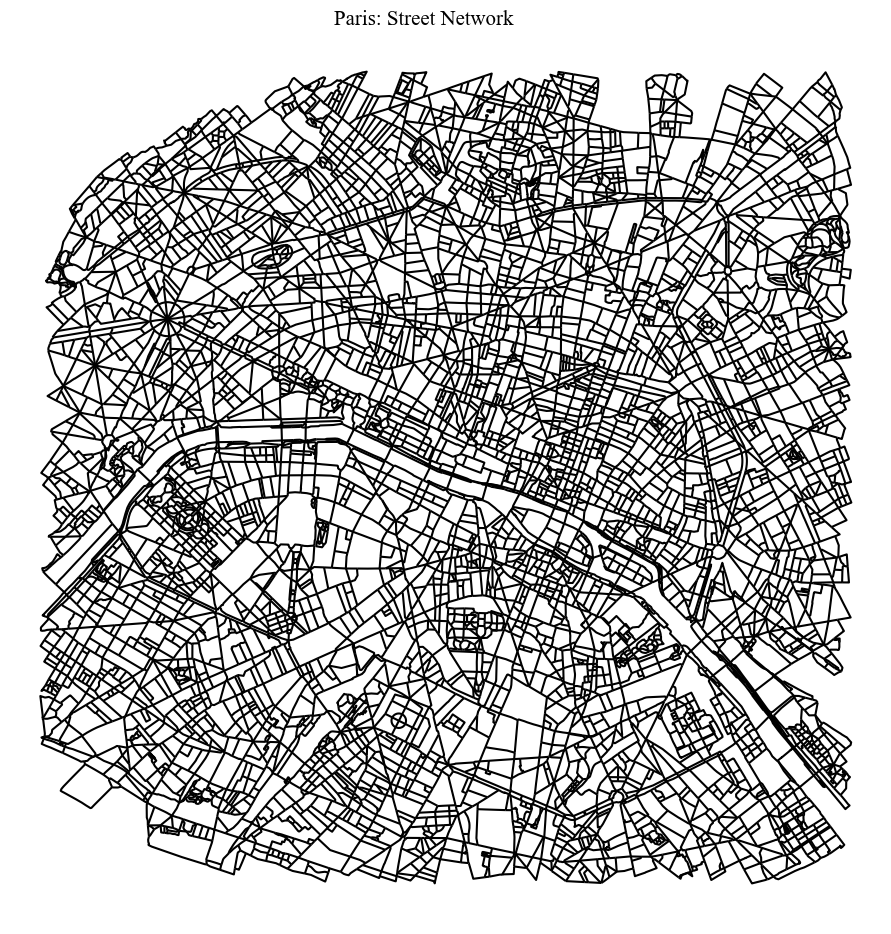

In [13]:
fig = ci.plot_gdf(edges_graph, black_background = False, geometry_size = 1.0, alpha = 1.0, 
                 color = 'black', title = city_name+': Street Network', figsize = (10,10))

### Assigning barriers to street segments
Type of Barriers:

* *Positive barriers*, from a pedestrian perspective: Waterbodies, Parks.
* *Negative barriers*, from a pedestrian perspective: Major Roads, Railway Structures.
* *Structuring barriers* - Barriers which structure and shape the image of the city: Waterbodies, Major roads, Railways.

In [14]:
# clipping barriers to case study area
envelope = edges_graph.unary_union.envelope
barriers_within = barriers[barriers.intersects(edges_graph.unary_union.envelope)]

### Street Segments *Along* and *Within* Positive Barriers

In [15]:
sindex = edges_graph.sindex
# rivers
edges_graph = ci.along_water(edges_graph, barriers_within)
# parks
edges_graph = ci.along_within_parks(edges_graph, barriers_within)
# altogheter
edges_graph['p_barr'] = edges_graph['a_rivers']+edges_graph['w_parks']
edges_graph['p_barr'] = edges_graph.apply(lambda row: list(set(row['p_barr'])), axis = 1)

### Street Segments *Along* Negative Barriers

In [16]:
tmp = barriers_within[barriers_within['barrier_type'].isin(['railway', 'road'])]
edges_graph['n_barr'] = edges_graph.apply(lambda row: ci.barriers_along(row['edgeID'], edges_graph, tmp, sindex,
                                            offset = 25), axis = 1)

### Street Segments *Crossing* any kind of barrier but parks: Structuring Barriers

In [17]:
edges_graph = ci.assign_structuring_barriers(edges_graph, barriers_within)

**Visualisation.** The cell below maps the result using the cityImage plotting helpers such as [plot_gdf](../api/cityImage.plot_gdf.rst#cityImage.plot_gdf); see the [Plotting section of the API reference](../api.rst) for all styling options.

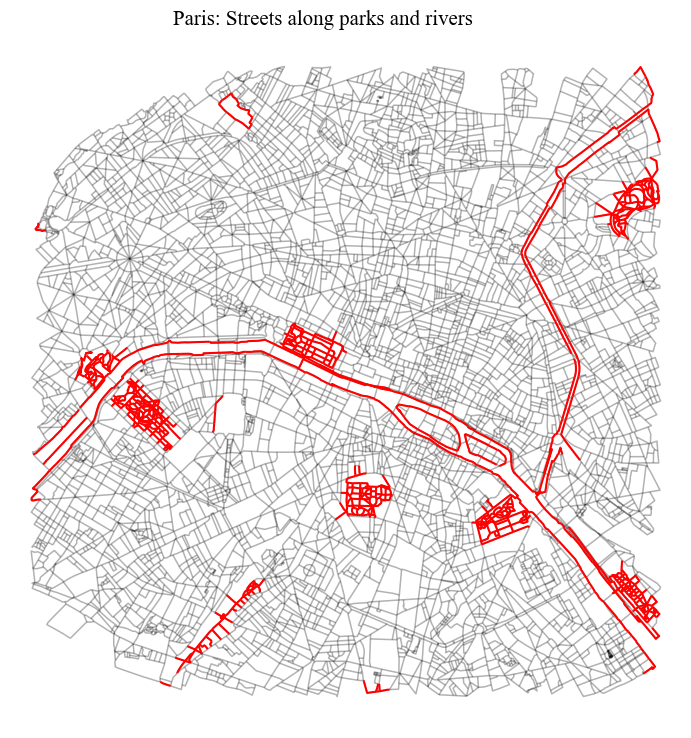

In [18]:
# positive barriers
edges_graph['p_bool'] = edges_graph.apply(lambda row: len(row['p_barr']) > 0, axis = 1)
tmp = edges_graph[edges_graph.p_bool].copy()

# base map
base_map_dict = {'base_map_gdf': edges_graph, 'base_map_alpha' : 0.3, 'base_map_color' : 'black'}
fig = ci.plot_gdf(tmp, black_background = False, figsize = (8, 8), color = 'red', title = city_name+': Streets across/along parks and rivers', 
              legend = False, **base_map_dict)

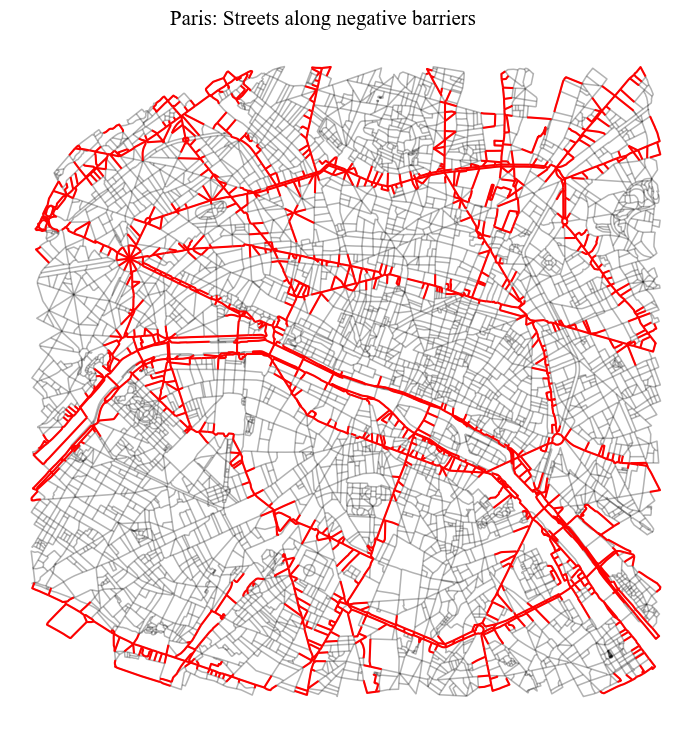

In [19]:
# negative barriers
edges_graph['n_bool'] = edges_graph.apply(lambda row: len(row['n_barr']) > 0, axis = 1)
tmp = edges_graph[edges_graph.n_bool].copy()

# base map
fig = ci.plot_gdf(tmp, black_background = False, figsize = (8, 8), color = 'red', title = city_name+': Streets along negative barriers',
              legend = False, **base_map_dict)

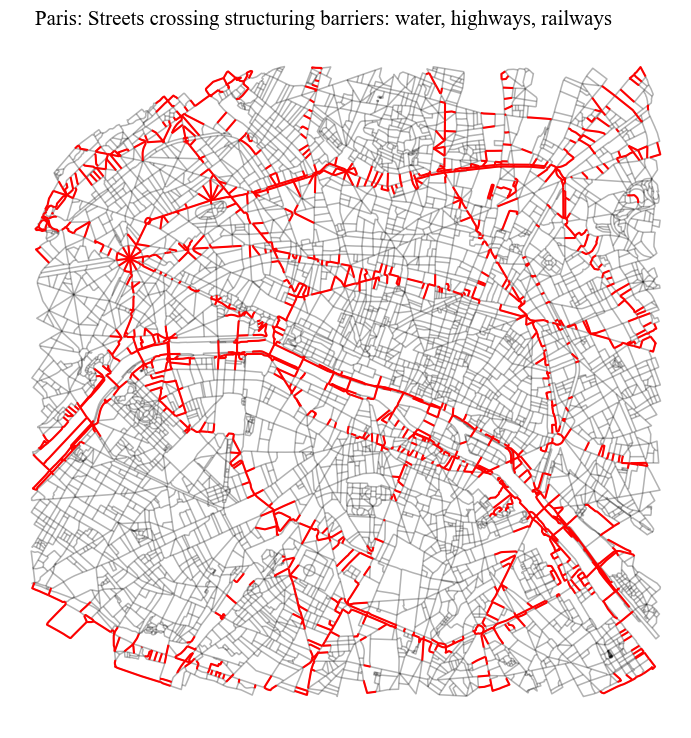

In [22]:
# separating barriers
tmp = edges_graph[edges_graph.sep_barr].copy()
fig = ci.plot_gdf(tmp, black_background = False, figsize = (8, 8),  color = 'red', 
            title = city_name+': Streets crossing structuring barriers: water, highways, railways',
             **base_map_dict)

**Exporting.** The results are written to disk as GeoPackage files with GeoPandas' `to_file`, ready to be reused in later notebooks or in external GIS software.

In [23]:
# saving barriers_gdf
output_path = '../output/'+city_name
barriers.to_file(output_path+"_barriers.gpkg", driver='GPKG')

# converting list fields to string
to_convert = ['a_rivers', 'w_parks','n_barr', 'p_barr']
edges_graph_string = edges_graph.copy()
for column in to_convert: 
    edges_graph_string[column] = edges_graph_string[column].astype(str)

edges_graph_string.to_file(output_path+"_edges_ped.gpkg", driver='GPKG')
nodes_graph.to_file(output_path+'_nodes_ped.gpkg', driver='GPKG')